In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
path = r"H:\PYTHON\etapa3\atividade 3 - 0,5 ponto\Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx"

In [24]:
df = pd.read_excel(arquivo, skiprows=3, header=None)

1. Homens e mulheres por região com curso superior

In [25]:
df_superior = df.iloc[:, [0, 1, 2, 3]].copy()
df_superior.columns = ['Regiao', 'Total_Superior', 'Homens_Superior', 'Mulheres_Superior']

 2. Homens e mulheres por região com curso em Ciência, Tecnologia, Engenharias e Matemática

In [26]:
df_tecnologia = df.iloc[:, [0, 4, 5, 6]].copy()
df_tecnologia.columns = ['Regiao', 'Total_STEM', 'Homens_STEM', 'Mulheres_STEM']

3. Homens e mulheres por região em Educação, Serviços pessoais, Saúde e Bem-estar

In [27]:
df_saude_educacao = df.iloc[:, [0, 7, 8, 9]].copy()
df_saude_educacao.columns = ['Regiao', 'Total_Saude_Ed', 'Homens_Saude_Ed', 'Mulheres_Saude_Ed']

 Exportando as três tabelas para formato .xlsx

In [28]:
df_superior.to_excel("curso_superior.xlsx", index=False)
df_tecnologia.to_excel("tecnologia.xlsx", index=False)
df_saude_educacao.to_excel("saude_educacao.xlsx", index=False)

Exibindo as estatísticas com describe()

In [29]:
print("1 - curso superior geral")
print(df_superior.describe())
print("\n" + "="*50 + "\n")

print("2 - ciencia, tecnologia, engenharia, matematica")
print(df_tecnologia.describe())
print("\n" + "="*50 + "\n")

print("3 - educacão, serviços, saúde e bem-estar")
print(df_saude_educacao.describe())

1 - curso superior geral
       Total_Superior  Homens_Superior  Mulheres_Superior
count    3.300000e+01     3.300000e+01       3.300000e+01
mean     2.350390e+06     9.525940e+05       1.397796e+06
std      4.937750e+06     2.020681e+06       2.918446e+06
min      6.704500e+04     2.558500e+04       4.146000e+04
25%      3.399130e+05     1.311780e+05       2.015070e+05
50%      7.167190e+05     2.850130e+05       4.036650e+05
75%      1.687930e+06     6.954250e+05       9.925050e+05
max      2.585429e+07     1.047853e+07       1.537576e+07


2 - ciencia, tecnologia, engenharia, matematica
         Total_STEM   Homens_STEM  Mulheres_STEM
count  3.300000e+01  3.300000e+01   3.300000e+01
mean   3.771856e+05  2.500382e+05   1.271471e+05
std    8.193451e+05  5.490790e+05   2.707352e+05
min    8.016000e+03  4.958000e+03   3.057000e+03
25%    4.634000e+04  2.824100e+04   1.645900e+04
50%    9.906200e+04  6.393500e+04   3.210900e+04
75%    2.556350e+05  1.665790e+05   8.905600e+04
max    4.14

In [30]:
brasil_df = pd.DataFrame(
    {
        "Área": [
            "Graduação (Total)",
            "STEM (Tecnologia)",
            "Saúde e Educação",
        ],
        "Homens": [
            df_superior.loc[
                df_superior["Regiao"] == "Brasil", "Homens_Superior"
            ].item(),
            df_tecnologia.loc[
                df_tecnologia["Regiao"] == "Brasil", "Homens_STEM"
            ].item(),
            df_saude_educacao.loc[
                df_saude_educacao["Regiao"] == "Brasil", "Homens_Saude_Ed"
            ].item(),
        ],
        "Mulheres": [
            df_superior.loc[
                df_superior["Regiao"] == "Brasil", "Mulheres_Superior"
            ].item(),
            df_tecnologia.loc[
                df_tecnologia["Regiao"] == "Brasil", "Mulheres_STEM"
            ].item(),
            df_saude_educacao.loc[
                df_saude_educacao["Regiao"] == "Brasil", "Mulheres_Saude_Ed"
            ].item(),
        ],
    }
)

In [31]:
brasil_long = brasil_df.melt(
    id_vars="Área", var_name="Sexo", value_name="Pessoas"
)

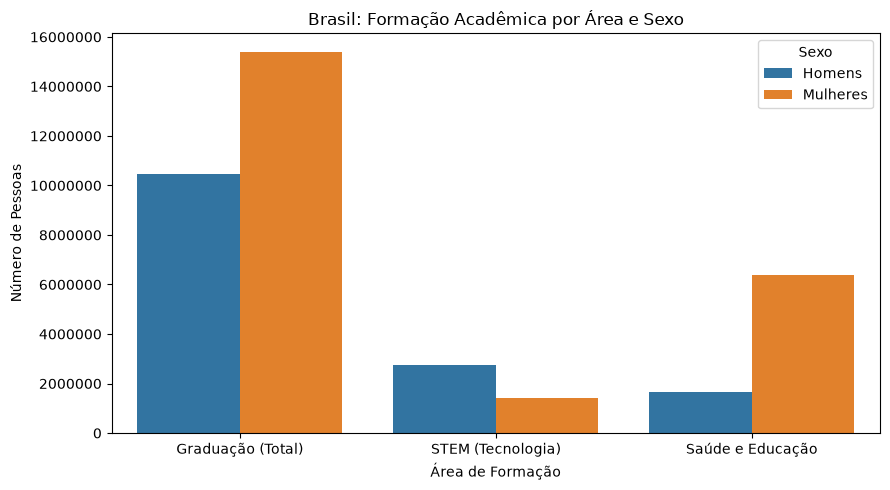

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=brasil_long, x="Área", y="Pessoas", hue="Sexo", ax=ax)

ax.set_title("Brasil: Formação Acadêmica por Área e Sexo")
ax.set_xlabel("Área de Formação")
ax.set_ylabel("Número de Pessoas")
ax.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()